# When people stop quitting, is a market drop coming? 🧑‍🏭
### The JOLTS 'quits rate' as a worker-confidence crystal ball, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leading_gauge%3F: Not_supported](https://img.shields.io/badge/Leading_gauge%3F-Not_supported-8b949e?style=flat-square)

Every month the U.S. reports how many workers **voluntarily quit** their jobs — the JOLTS *quits rate*. The logic is lovely: you only quit when you're confident you'll land something better, so a **high** quits rate means workers feel great, and a **falling** one means confidence is draining away. And if workers are the first to sense trouble, a **drop in quits should warn you before stocks — especially economically-sensitive 'cyclical' stocks — roll over.**

Great story. Testable story. This notebook asks three blunt questions: when quits fall, does the market really do worse? Does the quits drop actually come **first** (the whole pitch)? And if you *sold* every time quits fell, would you make money?

> 📓 **Plain-language layer.** Want the *t*-stats, the lead/lag cross-correlation and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A timing note up front.** JOLTS is published **~6 weeks late** — the March quits rate isn't out until early May. So an honest trader can only act on a reading **two months after** the fact. We build that delay in (no peeking). The quits numbers are the official settled prints (FRED `JTSQUR`), hardcoded so this is reproducible; every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from jolts_quits import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("SPY cache present:", HAVE_REAL,
      "| quits+SPY months:", (0 if F is None else len(F)),
      "| cyclicals:", data.have_cyclicals())

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-12-31', 'end': '2026-05-31', 'months': 306, 'years': 25.4, 'frac_falling': 29, 'h1': (1, 89, 0.62, 0.94, 0.84, 35, 35, -0.4, 0.308), 'h3': (3, 88, 2.1, 2.67, 2.51, 30, 29, -0.4, 0.302), 'h6': (6, 87, 5.65, 4.9, 5.12, 26, 25, 0.36, 0.679), 'h12': (12, 84, 11.39, 10.55, 10.79, 20, 19, 0.27, 0.635), 'leadlag': {-6: 0.046, -5: 0.075, -4: 0.217, -3: 0.195, -2: 0.138, -1: -0.04, 0: 0.056, 1: 0.077, 2: 0.031, 3: 0.03, 4: -0.004, 5: -0.032, 6: -0.059}, 'overlay': (9.7, 0.64, 8.1, 0.69, 7.8, 0.66, 90, 8.7, 6.0), 'cyc': [(1, 89, 0.28, 0.34, -0.1, 0.451), (3, 88, 1.15, 0.92, 0.22, 0.616), (6, 87, 3.15, 1.72, 1.14, 0.917), (12, 84, 6.33, 3.64, 1.66, 0.969)], 'robust': [('k=1', 85, 9.5, 10.8, -0.61, 0.227), ('k=3', 84, 11.4, 10.8, 0.27, 0.635), ('k=6', 97, 13.8, 10.8, 1.33, 0.971), ('thr>0.2pp', 19, 12.4, 10.8, 0.26, 0.66), ('ex-COVID', 80, 11.0, 11.8, -0.37, 0.321)], 'lag': {0: -0.25, 1: 0.1, 2: 0.27}, 'syn': [(0.0, 138, 1.48, 1.03, 1.15, 0.905), (0.04, 138, -1.92, -0.85, -2.64, 0.002)]}


SPY cache present: True | quits+SPY months: 306 | cyclicals: True


## The answer first

| Question | Answer |
|---|---|
| When quits fall, does the market do worse? | **Not really.** Over the next few months SPY is a touch below average (**+0.6%** vs **+0.8%** at 1 month) — but by 6–12 months it's a touch *above*. The sign flips; there's no reliable effect. |
| Is any of it reliable? | **No.** Every gap is tiny and well inside the noise — the strongest reading is a *t* of −0.4, and you can flip the answer just by changing the lookback. |
| Do the quits fall *first*? | **No — this is the killer.** The quits signal lines up best with a market move that already happened **three-to-four months earlier.** Quits *follow* stocks; they don't lead them — and then you learn the number 6 weeks late on top. |
| So could you trade it? | **It loses.** "Go to cash when quits fall" turned $1 into **6.0×** vs **8.7×** for just holding — you give up a third of your money for a Sharpe that's a rounding-tie. |

> Quits and the business cycle are real. But "falling quits warn you *early*" is a coincident echo wearing a crystal-ball costume — reported too late to act on, and pointing the wrong way as often as the right one.

## 1 · The claim

> *"The quits rate is worker confidence made visible. People quit only when they're sure they can do better, so a **falling** quits rate means confidence is cracking — get defensive, and especially lighten up on cyclicals, because the labour market turns before the stock market does."*

There's a respectable backbone here. Quits genuinely track the labour cycle — they collapsed in 2009 (nobody dared quit) and exploded in the 2021 'Great Resignation.' Fed officials watch the quits rate as a real-time read on labour-market heat. The *trading* leap is the part we test: that a quits **downturn** arrives early enough, and cleanly enough, to be a **tradable** warning for equities.

## 2 · So what?

If true, this would be a gift: a free, monthly, government number telling you to step aside before drawdowns. But 'the labour market leads' hides a trap. The **stock market is itself a leading indicator** — it usually turns *before* the economy. So a labour gauge that lines up with market weakness might not be *predicting* the market at all; it might just be **echoing** a turn the market already made. Worse, quits are a **slow, sticky** series reported six weeks late — the opposite of a fast trigger. The difference between *leads* and *echoes* is the difference between an edge and a mirage, and you can only tell them apart by checking the timing carefully.

## 3 · How would we even know?

We line up **25 years** (2000–2026, 306 months) of the JOLTS quits rate against month-end SPY, and:

1. **Split the months.** Call quits **falling** when the rate is below where it was three months ago. Compare what SPY did next (1/3/6/12 months) in falling-quits months vs all months — entering **two months after** the reference month, because that's when JOLTS is actually published.
2. **Check the timing.** The crucial test: slide quits forward and backward against the market and find *where* they line up best. If quits truly **lead**, the strongest link shows up at a **positive lead** (quits first, market later).
3. **Try to trade it.** Sit in cash whenever quits are falling, hold otherwise, pay realistic costs — and see if it beats just buying and holding.

## 4 · The teardown — let's actually look

**First, the raw material.** Here's the quits rate over a quarter-century — the 2009 collapse (workers too scared to quit), the long climb, and the off-the-chart 2021 'Great Resignation' spike. Quits clearly *know* about the cycle. The question is whether they know **early**.

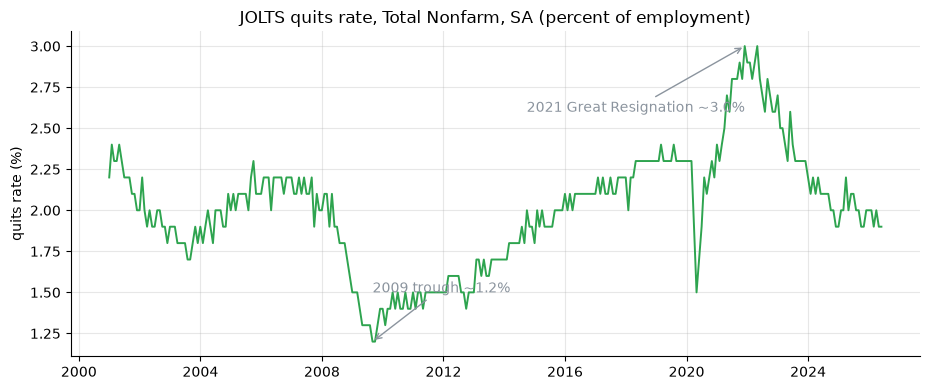

range: 1.2 to 3.0 (%)


In [2]:
if HAVE_REAL:
    q = F['quits']
    fig, ax = plt.subplots(figsize=(9.4, 4.0))
    ax.plot(q.index, q.values, c=GREEN, lw=1.4)
    ax.set_title('JOLTS quits rate, Total Nonfarm, SA (percent of employment)')
    ax.set_ylabel('quits rate (%)')
    ax.annotate('2009 trough ~1.2%', xy=(q.idxmin(), q.min()), xytext=(q.idxmin(), 1.5),
                arrowprops=dict(arrowstyle='->', color=GREY), color=GREY)
    ax.annotate('2021 Great Resignation ~3.0%', xy=(q.idxmax(), q.max()), xytext=(q.idxmax(), 2.6),
                ha='right', arrowprops=dict(arrowstyle='->', color=GREY), color=GREY)
    plt.tight_layout(); plt.show()
    print('range:', q.min(), 'to', q.max(), '(%)')
else:
    print('no cache — see docs/results.md; quits ranged 1.2% (2009) to 3.0% (2021)')

**Now the payoff.** For each horizon, the average forward SPY return in **falling-quits** months next to the return on an **average** month. The folklore predicts the red bars sit *below* the grey ones — at every horizon.

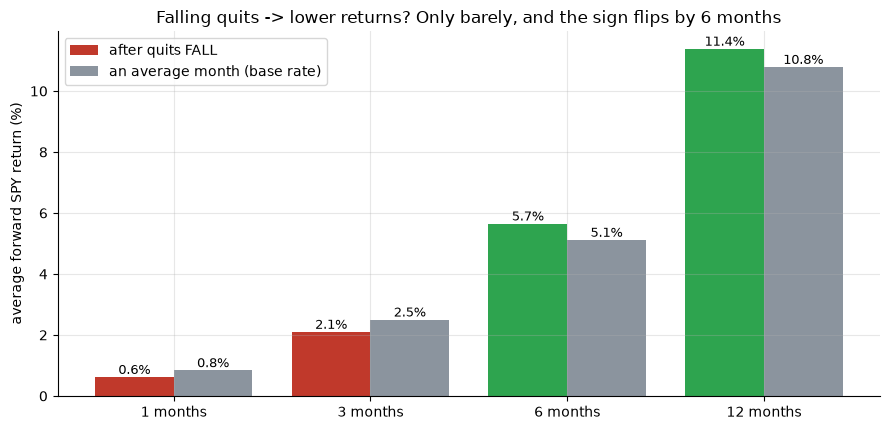

1m: falling 0.6% vs base 0.8% | 12m: falling 11.4% vs base 10.8%


In [3]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    rows = [st.summarize(F, m) for m in hs]
    fal = [r['falling_mean']*100 for r in rows]; base = [r['base_mean']*100 for r in rows]
else:
    fal = [R['h1'][2], R['h3'][2], R['h6'][2], R['h12'][2]]
    base = [R['h1'][4], R['h3'][4], R['h6'][4], R['h12'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [RED if a < b else GREEN for a, b in zip(fal, base)]
ax.bar(x-.2, fal, .4, color=cols, label='after quits FALL')
ax.bar(x+.2, base, .4, color=GREY, label='an average month (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('average forward SPY return (%)')
ax.set_title('Falling quits -> lower returns? Only barely, and the sign flips by 6 months')
for i,(a,b) in enumerate(zip(fal,base)):
    ax.annotate(f'{a:.1f}%',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('1m: falling', f'{fal[0]:.1f}%', 'vs base', f'{base[0]:.1f}%',
      '| 12m: falling', f'{fal[-1]:.1f}%', 'vs base', f'{base[-1]:.1f}%')

Look what happens across the row. At 1–3 months falling-quits returns sit *just* below the base rate (the folklore's direction) — but by 6 and 12 months they're *above* it (**+11.4%** vs **+10.8%** at a year). The effect can't decide which way it points, and every gap is a fraction of a percent. Hold that thought; the *next* chart is where the story breaks for good.

**The crucial test: do the quits fall *first*?** We slide quits forward and backward against the market and measure how tightly they move together. A real leading gauge would show its strongest link at a **positive lead** (quits lead → bar peaks on the right). Watch where it actually peaks.

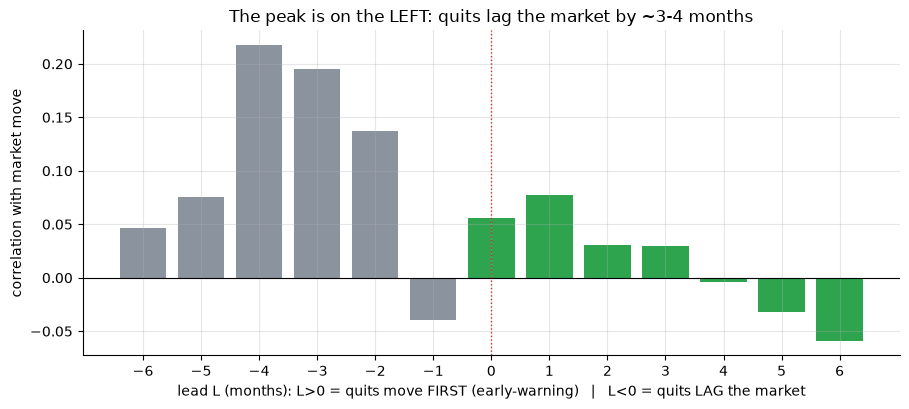

strongest link at L=-4 months (quits FOLLOW the market here)


In [4]:
if HAVE_REAL:
    ll = st.lead_lag(F)
    Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [GREY if L<0 else GREEN for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=RED, lw=1, ls=':')
ax.set_xlabel('lead L (months): L>0 = quits move FIRST (early-warning)   |   L<0 = quits LAG the market')
ax.set_ylabel('correlation with market move'); ax.set_xticks(Ls)
ax.set_title('The peak is on the LEFT: quits lag the market by ~3-4 months')
plt.tight_layout(); plt.show()
imax = int(np.nanargmax(cs))
print(f'strongest link at L={Ls[imax]} months (quits FOLLOW the market here)')

There it is. The tallest bar is at **L = −4** — the quits signal lines up best with a market move that happened **three-to-four months earlier**. On the right, where a true early-warning would live (quits moving first), the bars are near zero. **Quits aren't leading the market — they're trailing it.** The cycle shows up in stock prices, and only later in the quits rate — which you then read six weeks after *that*.

**Could you trade it anyway?** Suppose you sold (went to cash) whenever quits were falling and held SPY otherwise — acting two months late, as JOLTS forces you to. Here's that strategy's growth of $1 vs just buying and holding.

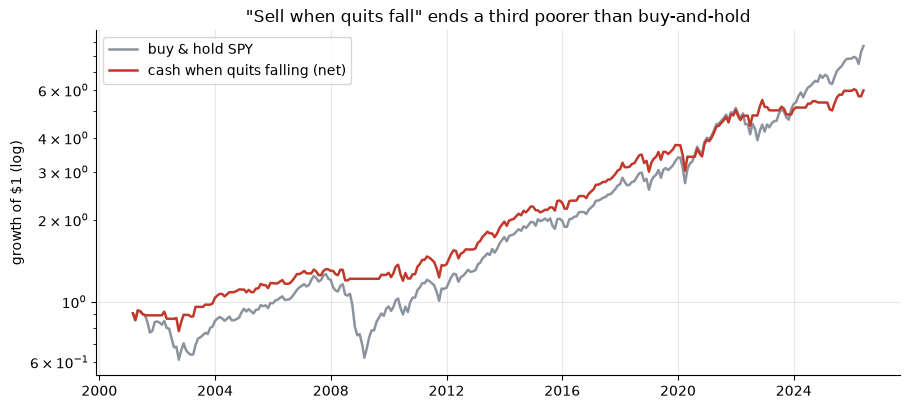

final $1 -> buy&hold 8.7x  vs  overlay 6.0x


In [5]:
if HAVE_REAL:
    import pandas as pd
    falling = st.falling_mask(F); pos = (~falling).astype(float).shift(2)
    rr = F['spy'].pct_change()
    dfp = pd.DataFrame({'r': rr, 'pos': pos}).dropna()
    sw = dfp['pos'].diff().abs().fillna(0); c=10/1e4
    overlay = (dfp['pos']*dfp['r'] - sw*c)
    bh_grow = (1+dfp['r']).cumprod(); ov_grow = (1+overlay).cumprod()
    fig, ax = plt.subplots(figsize=(9.2, 4.2))
    ax.plot(bh_grow.index, bh_grow.values, c=GREY, lw=1.8, label='buy & hold SPY')
    ax.plot(ov_grow.index, ov_grow.values, c=RED, lw=1.8, label='cash when quits falling (net)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('"Sell when quits fall" ends a third poorer than buy-and-hold')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final $1 -> buy&hold {bh_grow.iloc[-1]:.1f}x  vs  overlay {ov_grow.iloc[-1]:.1f}x')
else:
    print(f"overlay {R['overlay'][8]:.1f}x vs buy-hold {R['overlay'][7]:.1f}x terminal — see results.md")

The defensive overlay ends up **well below** buy-and-hold — **6.0×** vs **8.7×** on $1, **+7.8%/yr** vs **+9.7%/yr**. Its Sharpe is a fraction higher (0.66 vs 0.64) — but *only* because it's out of the market ~29% of the time. That's not skill; it's just less exposure. You handed back a third of your wealth to lower your risk a little — a trade you could make more cheaply by just holding less SPY.

## 5 · The verdict

- **Signal — None.** Falling quits don't reliably precede weaker returns: the effect is tiny, insignificant (best *t* = −0.4), and it **flips sign** between the short and long horizon. Point the lookback one way and it's bearish; point it the other and it's bullish. That's noise.
- **Tradability — Mirage.** Selling on falling quits **ends a third poorer** than buy-and-hold. The whisper of a higher Sharpe is just de-risking — beta you dialled down, not alpha you found.
- **Leading gauge? — Not supported.** The quits drop lines up with a market move that already happened a quarter earlier — and you read the number six weeks after it's stale. Quits **echo** equity weakness; they don't forecast it. The one word that makes the pitch — *early* — is the part the data rejects.

## 6 · Could you actually trade it? — the honest bottom line

Forget significance for a second. Even if the tiny tilt were real, the operational reality kills it twice. First, **JOLTS is six weeks late** — by the time you know March's quits fell, it's May, and any 'early' warning has long since played out in prices. Second, the claim's own favourite target — **cyclicals** — actually does *better* after quits fall (cyclicals lead the recovery the quits reading is lagging into), so the sector bet is backwards. There is no version of "sell when quits fall" that both fires early *and* makes money.

## 7 · Going further 🚪

- **The sibling test.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/) asks the same question of *rising jobless claims* — same result: a coincident labour echo, not a tradable lead.
- **More macro crystal balls.** [Study 384 — ISM-PMI-Regime](../384-ism-pmi-regime/) and [Study 387 — Economic-Surprise-Index](../387-economic-surprise-index/) put other celebrated gauges through the same wringer.
- **Build your own.** Swap the quits *rate* for hires, or pair quits with a *price* trend filter — the lead/lag picture barely budges: a coincident series can't be made to lead by smoothing it differently, and the publication delay is baked into the data.

*Think quits lead the market? Show the lead/lag chart peaking on the **right** (positive lead) — then we'll talk.*